In [1]:
import os
import uuid
import imageio
import numpy as np
from IPython.display import Image as ImageDisplay
import sys
PATH = os.getcwd()
module_dir = os.path.abspath(f"{PATH}/../sam-3d-objects/notebook/")
sys.path.append(module_dir)
from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer
import torch
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from skimage.measure import ransac
from skimage.transform import SimilarityTransform

import open3d as o3d

/home/haihong/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 2000 Ada Generation" (16 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/haihong/.cache/warp/1.11.1


2026-03-10 10:02:01.659 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA RTX 2000 Ada Generation


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-10 10:02:02.882 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-10 10:02:04.978 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-10 10:02:05.919 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-10 10:02:05.920 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")
print(outputs[0].keys())
# Access your intrinsics directly
print(outputs[0]['rotation'])
print(outputs[0]['pointmap'].shape)
print(outputs[0]['coords'])

/tmp/ipykernel_50841/3177310871.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")


dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors', 'intrinstics'])
tensor([[ 0.1910, -0.9665, -0.0667, -0.1580]], device='cuda:0')
torch.Size([480, 640, 3])
tensor([[ 0, 16, 16, 20],
        [ 0, 16, 16, 21],
        [ 0, 16, 16, 22],
        ...,
        [ 0, 47, 46, 43],
        [ 0, 47, 46, 44],
        [ 0, 47, 46, 45]], device='cuda:0', dtype=torch.int32)


In [15]:
import open3d as o3d
import time

def safe_visualize(geometries):
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name="Alignment", width=800, height=600)
    
    for geom in geometries:
        vis.add_geometry(geom)
    
    # Manually update the renderer
    for _ in range(100):
        vis.update_geometry(None)
        vis.poll_events()
        vis.update_renderer()
        time.sleep(0.01)
    
    vis.run() # This starts the interaction
    vis.destroy_window()
    
def debug_splats_3d(scene_gs, dynosam_df):
    pts = scene_gs.get_xyz.cpu().numpy()
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.paint_uniform_color([1, 0, 0])

    pcd_dyno = o3d.geometry.PointCloud()
    pcd_dyno.points = o3d.utility.Vector3dVector(dynosam_df[['x_world', 'y_world', 'z_world']].values)
    pcd_dyno.paint_uniform_color([0, 1, 0])

    pcd_reduced = o3d.geometry.PointCloud()
    pcd_reduced.points = o3d.utility.Vector3dVector(dynosam_df[['x_gs', 'y_gs', 'z_gs']].values)
    pcd_reduced.paint_uniform_color([0, 0, 1])
    
    # Add a coordinate frame to see the center of the scene
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5)
    
    o3d.visualization.draw_geometries([pcd, pcd_dyno, pcd_reduced, axes])

In [4]:
import yaml

def extract_intrinsics_safe(yaml_path):
    # 1. Read the file as raw text to avoid ScannerError
    with open(yaml_path, 'r') as f:
        lines = f.readlines()

    # 2. Clean and parse manually into a dictionary
    config = {}
    for line in lines:
        # Strip comments and whitespace
        line = line.split('#')[0].strip()
        if not line or ':' not in line:
            continue
            
        # Split by the FIRST colon only
        key, value = line.split(':', 1)
        config[key.strip()] = float(value.strip())

    # 3. Build the 3x3 Intrinsic Matrix K
    # Using the keys exactly as they appear in your oxford.yaml
    K = np.array([
        [config['Camera.fx'], 0.0,               config['Camera.cx']],
        [0.0,               config['Camera.fy'], config['Camera.cy']],
        [0.0,               0.0,               1.0]
    ], dtype=np.float64)

    # 4. Build Distortion Coefficients
    dist_coeffs = np.array([
        config['Camera.k1'],
        config['Camera.k2'],
        config['Camera.p1'],
        config['Camera.p2'],
        config.get('Camera.k3', 0.0)
    ], dtype=np.float64)

    width = int(config['Camera.width'])
    height = int(config['Camera.height'])

    return K, dist_coeffs, width, height

# Usage
K_gt, distortion, width, height = extract_intrinsics_safe(f'{PATH}/../tracking_dataset/omd/oxford.yaml')
print("Intrinsic Matrix K:\n", K_gt)
print(width, height)

Intrinsic Matrix K:
 [[974.84096024   0.         637.95127169]
 [  0.         975.29699743 482.03693158]
 [  0.           0.           1.        ]]
1280 960


In [5]:
def to_numpy(x):
    if hasattr(x, 'detach'):
        x = x.detach().cpu().numpy()
    return np.array(x).squeeze()
M = np.eye(4)
M[:3, 3] = to_numpy(outputs[0].get('translation', [0, 0, 0]))                # Apply Translation
mesh = outputs[0]['glb']
mesh.apply_transform(M)

<trimesh.Trimesh(vertices.shape=(3388, 3), faces.shape=(6772, 3))>

In [6]:
def get_gs_pixel_correspondence(scene_gs, K_gt, width, height):
    """
    K_gt: The 3x3 matrix from your oxford.yaml
    scene_gs: The output from your make_scene function
    """
    xyz = to_numpy(scene_gs.get_xyz)  # [N, 3]
    
    # 1. Project to 2D using GT Intrinsics
    # Homo: [X*fx + Z*cx, Y*fy + Z*cy, Z]
    xyz_homo = (K_gt @ xyz.T).T
    z = xyz_homo[:, 2]
    
    # Filter points in front of camera
    mask_in_front = z > 0.01
    uv = xyz_homo[mask_in_front, :2] / z[mask_in_front, None]
    
    # 2. Map to Pixel Grid
    u = torch.tensor(uv[:, 0].round())
    v = torch.tensor(uv[:, 1].round())
    
    # 3. Boundary Check
    valid_pixels = (u >= 0) & (u < width) & (v >= 0) & (v < height)
    mask_in_front = torch.tensor(mask_in_front)
    
    # final_uv stores [u, v] for each splat that landed in the image
    splat_indices = torch.where(mask_in_front)[0][valid_pixels]
    final_uv = torch.stack([u[valid_pixels], v[valid_pixels]], dim=1)
    
    return final_uv, splat_indices

In [7]:
outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")
scene_gs = make_scene(*outputs)
final_uv, splat_indices = get_gs_pixel_correspondence(scene_gs, K_gt, width, height)



/tmp/ipykernel_50841/1693610369.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")


   frame_id  object_id  tracklet_id    u    v   x_world   y_world   z_world
0         1          1          540  396  319 -0.993514 -0.645680  4.160993
1         1          1          539  488  318 -0.570573 -0.614079  3.908110
2         1          1          538  397  295 -0.988477 -0.743213  4.142187
3         1          1          536  396  283 -0.990679 -0.794118  4.137121
4         1          1          534  397  358 -0.992766 -0.483458  4.178058


/tmp/ipykernel_50841/3635714513.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(object_ids))


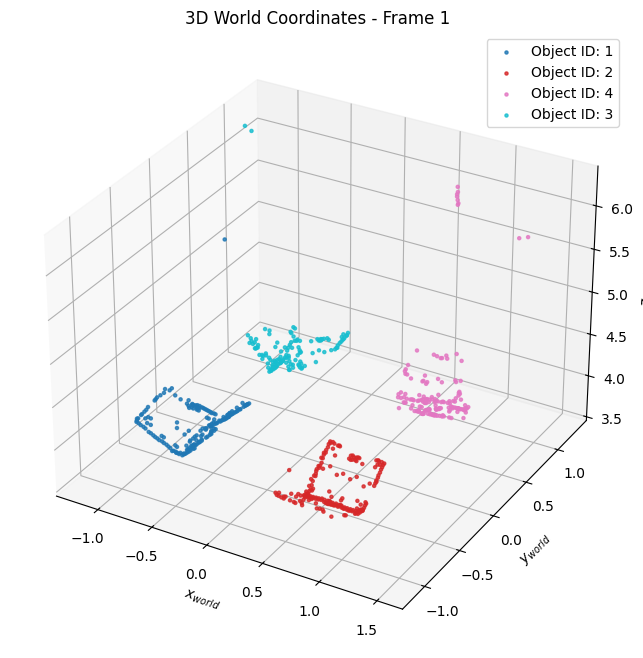

In [9]:

df_pixel_coord = pd.read_csv(f"{PATH}/../results/exp1/pixel_coords_debug.csv", header=None)
df_pixel_coord.columns = ['frame_id', 'object_id', 'tracklet_id', 'u', 'v']
df_3d_coord = pd.read_csv(f"{PATH}/../results/exp1/frontend_map_points_log.csv")

df = pd.merge(
    df_pixel_coord, 
    df_3d_coord, 
    on=['frame_id', 'object_id', 'tracklet_id'], 
    how='inner'
)
print(df.head())

frame_1 = df[df['frame_id'] == 1]

# 2. Setup the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Get unique object IDs to assign colors
object_ids = frame_1['object_id'].unique()
colors = plt.cm.get_cmap('tab10', len(object_ids))

# 4. Plot each object group with a different color
for i, obj_id in enumerate(object_ids):
    obj_data = frame_1[frame_1['object_id'] == obj_id]
    ax.scatter(obj_data['x_world'], 
               obj_data['y_world'], 
               obj_data['z_world'], 
               label=f'Object ID: {int(obj_id)}',
               color=colors(i),
               s=5, alpha=0.8) # Point size

# 5. Labeling and formatting using LaTeX
ax.set_xlabel('$x_{world}$')
ax.set_ylabel('$y_{world}$')
ax.set_zlabel('$z_{world}$')
ax.set_title('3D World Coordinates - Frame 1')
ax.legend()
plt.show()

In [11]:
import torch
import pandas as pd
import numpy as np

def filter_splats_by_dynosam(final_uv, splat_indices, dynosam_df, width=1280, height=960):
    """
    Filters splat projections to only keep those that exist in the DynoSAM tracking data.
    """
    # 1. Create a boolean mask for the entire image resolution
    # This acts as a 'Validation Map'
    validation_map = np.zeros((height, width), dtype=bool)
    
    # 2. Extract valid pixels from DynoSAM dataframe
    # We use .values for faster access
    valid_u = dynosam_df['u'].values.astype(int)
    valid_v = dynosam_df['v'].values.astype(int)
    
    # Clip to ensure they are within bounds
    valid_u = np.clip(valid_u, 0, width - 1)
    valid_v = np.clip(valid_v, 0, height - 1)
    
    # Mark existing DynoSAM pixels as True
    validation_map[valid_v, valid_u] = True
    
    # 3. Convert validation_map to a Torch Tensor (on same device as final_uv)
    device = final_uv.device
    valid_mask_torch = torch.from_numpy(validation_map).to(device)
    
    # 4. Filter the Splat Projections
    # final_uv is [N, 2] -> [u, v]
    u_coords = final_uv[:, 0].long()
    v_coords = final_uv[:, 1].long()
    
    # Access the validation map at the projected coordinates
    keep_mask = valid_mask_torch[v_coords, u_coords]
    
    # 5. Apply the mask to both tensors
    filtered_uv = final_uv[keep_mask]
    filtered_indices = splat_indices[keep_mask]
    
    return filtered_uv, filtered_indices

# TODO: maybe weighted avearage will perform better?
def consolidate_gaussians_weighted_average(final_uv, splat_indices, scene_gs, dynosam_df, width=1280):
    """
    Consolidates multiple Gaussians per pixel using an opacity-weighted average.
    """
    xyz = scene_gs.get_xyz[splat_indices]         # [N, 3]
    opacity = torch.sigmoid(scene_gs._opacity[splat_indices]) # [N, 1]
    
    u = final_uv[:, 0].long()
    v = final_uv[:, 1].long()
    pixel_keys = v * width + u  # Unique ID for each pixel

    # 1. Compute Weights
    # We use opacity as the weight. You can also include scale if needed.
    weights = opacity
    weighted_xyz = xyz * weights
    
    # 2. Sum up weighted coordinates and total weights per pixel
    # We use 'scatter_add' logic
    unique_keys = torch.unique(pixel_keys)
    num_unique = unique_keys.shape[0]
    
    # Mapping pixel_keys to 0...num_unique indices for scatter
    _, inverse_indices = torch.unique(pixel_keys, return_inverse=True)
    
    sum_weighted_xyz = torch.zeros((num_unique, 3), device=xyz.device)
    sum_weights = torch.zeros((num_unique, 1), device=xyz.device)
    
    sum_weighted_xyz.index_add_(0, inverse_indices, weighted_xyz)
    sum_weights.index_add_(0, inverse_indices, weights)
    
    # 3. Final Average
    average_xyz = sum_weighted_xyz / (sum_weights + 1e-10)
    
    # 4. Map back to U, V
    # Get one instance of U, V for each unique pixel key
    # (Since they are grouped, any original UV in that group works)
    unique_uv = torch.zeros((num_unique, 2), device=xyz.device)
    unique_uv.index_copy_(0, inverse_indices, final_uv.float())
    
    return unique_uv.long(), average_xyz

# Usage:
filtered_uv, filtered_ids = filter_splats_by_dynosam(final_uv, splat_indices, frame_1)
# filtered_uv, filtered_ids = consolidate_gaussians_weighted_average(final_uv, splat_indices, frame_1)

In [12]:
def consolidate_gaussians_for_alignment(final_uv, splat_indices, scene_gs, dynosam_df):
    """
    Consolidates multiple Gaussians per pixel into a single 3D point 
    based on the closest depth (Z-buffer).
    """
    xyz = scene_gs.get_xyz[splat_indices] # [N, 3]
    u = final_uv[:, 0].long()
    v = final_uv[:, 1].long()
    
    # 1. Create a unique key for each pixel (u, v)
    # Using 'v * width + u' to create a 1D index
    width = 1280
    pixel_keys = v * width + u
    
    # 2. Sort by Depth (Z)
    # We want the smallest Z to be at the top for each pixel
    depths = xyz[:, 2]
    sorted_indices = torch.argsort(depths).to(pixel_keys.device)
    
    # Reorder everything by depth
    pixel_keys_sorted = pixel_keys[sorted_indices]
    xyz_sorted = xyz[sorted_indices]
    u_sorted = u[sorted_indices]
    v_sorted = v[sorted_indices]

    # 3. Keep only the first occurrence of each pixel_key (The closest point)
    # unique_consecutive only works on sorted keys, but we sorted by Z, not keys.
    # Instead, we use a dictionary-style reduction or a mask:
    
    # Get unique pixel keys and the index of their first occurrence (which is the min depth)
    unique_keys, first_occurrence_indices = np.unique(pixel_keys_sorted.cpu().numpy(), return_index=True)
    
    # 4. Extract consolidated 3D points and their UVs
    consolidated_xyz = xyz_sorted[first_occurrence_indices]
    consolidated_u = u_sorted[first_occurrence_indices]
    consolidated_v = v_sorted[first_occurrence_indices]

    # 5. Final Match with DynoSAM Dataframe
    # Create a lookup for DynoSAM 3D points based on (u, v)
    # Assuming dynosam_df has 'u', 'v', 'x', 'y', 'z' (the target points)
    
    matched_gaussians = []
    matched_dynosam = []

    # Efficient matching via merge
    gs_df = pd.DataFrame({
        'u': consolidated_u.cpu().numpy(),
        'v': consolidated_v.cpu().numpy(),
        'x_gs': consolidated_xyz[:, 0].cpu().numpy(),
        'y_gs': consolidated_xyz[:, 1].cpu().numpy(),
        'z_gs': consolidated_xyz[:, 2].cpu().numpy()
    })

    merged_df = pd.merge(gs_df, dynosam_df, on=['u', 'v'], how='inner')
    

    return merged_df

merged_df = consolidate_gaussians_for_alignment(filtered_uv, filtered_ids, scene_gs, frame_1)



Kept 96 inliers out of 120 points.
Alignment RMSE: 0.0486 meters
Excellent alignment! Suitable for precise satellite trajectory prediction.


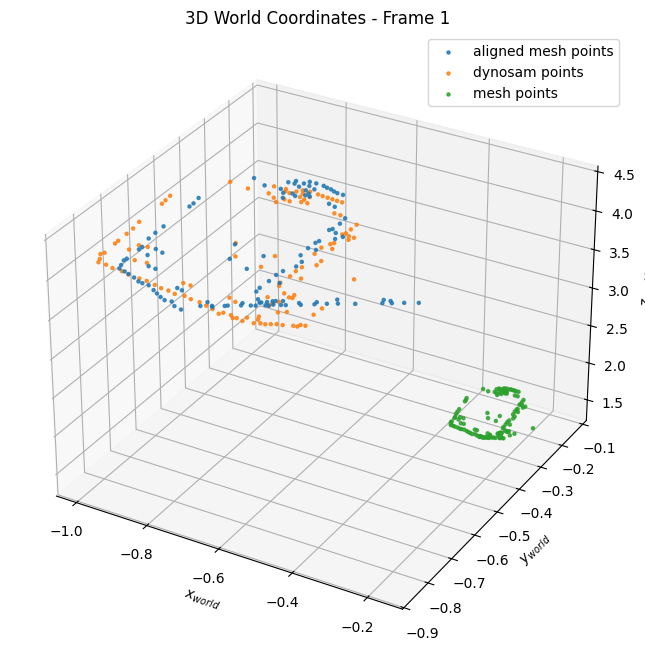

Kept 77 inliers out of 115 points.
Alignment RMSE: 0.0571 meters
Alignment has some jitter. Check for non-rigid motion or sensor noise.


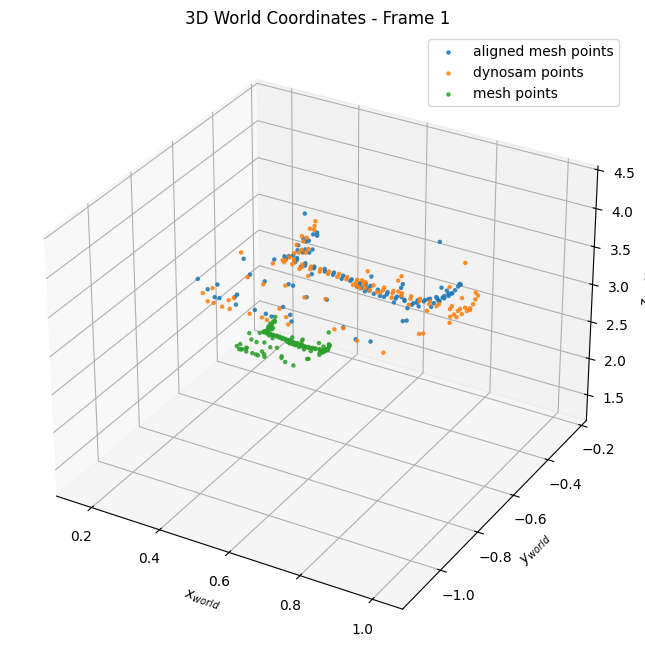

Kept 73 inliers out of 106 points.
Alignment RMSE: 0.0511 meters
Alignment has some jitter. Check for non-rigid motion or sensor noise.


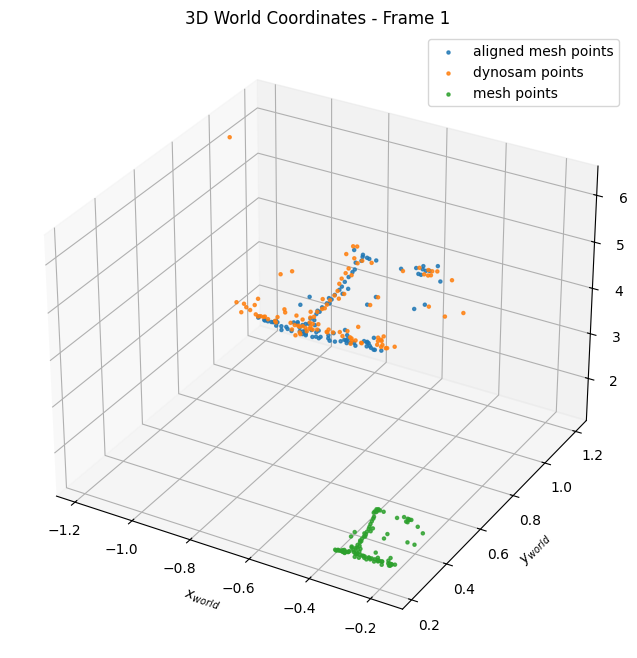

Kept 97 inliers out of 132 points.
Alignment RMSE: 0.0372 meters
Excellent alignment! Suitable for precise satellite trajectory prediction.


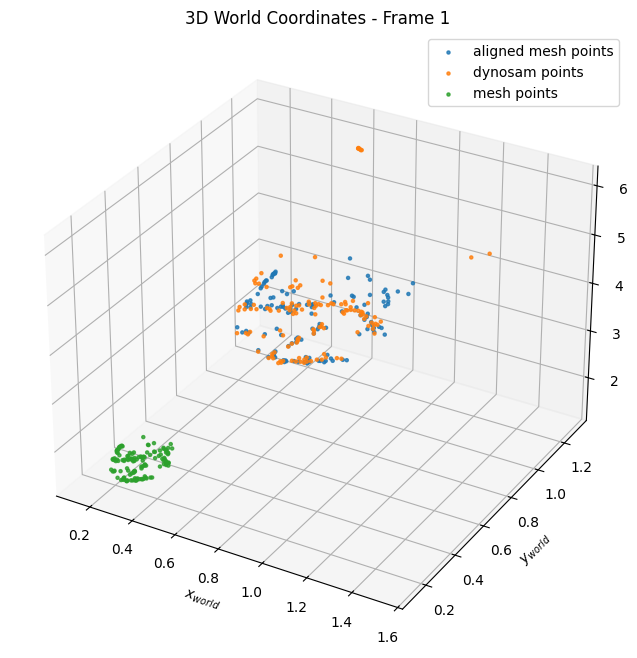

In [27]:
def apply_transformation_matrix(points, model):
    """
    Applies the full 4x4 similarity transformation matrix to a point cloud.
    
    points: [N, 3] numpy array (your SAM3D mesh points)
    model: The fitted skimage.transform.SimilarityTransform object
    """
    # 1. Convert to Homogeneous Coordinates (N, 3) -> (N, 4)
    # We add a column of ones so we can multiply by a 4x4 matrix
    n = points.shape[0]
    ones = np.ones((n, 1))
    
    points_homo = np.hstack([points, ones])
    
    # 2. Apply the transformation
    # P_new = P_old * M^T (standard row-vector multiplication)
    # model.params is the 4x4 matrix [ [sR, t], [0, 1] ]
    aligned_homo = points_homo @ model.params.T
    
    # 3. Convert back to Cartesian Coordinates (N, 4) -> (N, 3)
    # We simply drop the last column of 1s
    aligned_points = aligned_homo[:, :3]
    
    return aligned_points

def visualize_overlay(aligned_mesh_pts, mesh_pts, world_pts):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(aligned_mesh_pts[:, 0], 
               aligned_mesh_pts[:, 1], 
               aligned_mesh_pts[:, 2], 
                   label="aligned mesh points",
                   s=5, alpha=0.8) # Point size
    ax.scatter(world_pts[:, 0], 
               world_pts[:, 1], 
               world_pts[:, 2], 
                   label="dynosam points",
                   s=5, alpha=0.8) # Point size
    ax.scatter(mesh_pts[:, 0], 
               mesh_pts[:, 1], 
               mesh_pts[:, 2], 
                   label="mesh points",
                   s=5, alpha=0.8) # Point size
    
    # 5. Labeling and formatting using LaTeX
    ax.set_xlabel('$x_{world}$')
    ax.set_ylabel('$y_{world}$')
    ax.set_zlabel('$z_{world}$')
    ax.set_title('3D World Coordinates - Frame 1')
    ax.legend()
    plt.show()

def estimate_transform(df, object_id):
    # 1. Prepare data arrays
    df = df[df['object_id']==object_id]
    src = df[['x_gs', 'y_gs', 'z_gs']].values
    dst = df[['x_world', 'y_world', 'z_world']].values

    # 2. Preliminary Outlier Removal (Statistical)
    # This removes points that are physically far from the cluster center
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    good_mask = lof.fit_predict(src) == 1
    src_clean = src[good_mask]
    dst_clean = dst[good_mask]


    # 3. RANSAC with SimilarityTransform (Umeyama)
    # This handles Scale, Rotation, and Translation
    model, inliers = ransac(
        (src_clean, dst_clean),
        SimilarityTransform, 
        min_samples=3,
        residual_threshold=0.1, # Max error allowed (in meters)
        max_trials=1000
    )

    print(f"Kept {sum(inliers)} inliers out of {len(src_clean)} points.")
    
    
    # Apply to your full mesh points
    all_mesh_pts = src_clean
    aligned_mesh_pts = apply_transformation_matrix(all_mesh_pts, model)

    # Apply to your tracking points (optional, if they aren't already world-space)
    world_pts = dst_clean
    
    # Calculate error for the inliers (the points used for alignment)
    diff = aligned_mesh_pts[inliers] - world_pts[inliers]
    rmse = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    
    print(f"Alignment RMSE: {rmse:.4f} meters")
    if rmse < 0.05:
        print("Excellent alignment! Suitable for precise satellite trajectory prediction.")
    else:
        print("Alignment has some jitter. Check for non-rigid motion or sensor noise.")

    visualize_overlay(aligned_mesh_pts, all_mesh_pts, world_pts)
    
    return model, inliers, aligned_mesh_pts, all_mesh_pts, world_pts

models = []
for i in range(4):
    model, inliers, aligned_mesh_pts, all_mesh_pts, world_pts = estimate_transform(merged_df, i+1)
    models.append(model)


In [ ]:
from scipy.spatial.transform import Rotation as R_tool
from copy import deepcopy
from sam3d_objects.utils.visualization import SceneVisualizer
from pytorch3d.transforms import quaternion_multiply, quaternion_invert


def quaternion_multiply_batch(q, p):
    """
    Multiplies a single quaternion q with a batch of quaternions p.
    Assumes [x, y, z, w] format.
    """
    x1, y1, z1, w1 = q
    x2, y2, z2, w2 = p[:, 0], p[:, 1], p[:, 2], p[:, 3]
    
    res_x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    res_y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    res_z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2
    res_w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    
    return torch.stack([res_x, res_y, res_z, res_w], dim=-1)
    

def make_scene_modified(*outputs, models, in_place=False):
    if not in_place:
        outputs = [deepcopy(output) for output in outputs]



    all_outs = []
    minimum_kernel_size = float("inf")
    for i, output in enumerate(outputs):
        #----- prepare transformation params ---
        device = outputs[0]["gaussian"][0].get_xyz.device
        
        # 1. Prepare Tensors
        target_scale = models[i].scale
        target_translation = models[i].translation
        target_rotation = models[i].rotation
        M = torch.as_tensor(models[i].params, device=device, dtype=torch.float32)
        # x, y axis inversion
        F = torch.eye(4, device=device)
        F[0, 0] = -1.0
        F[1, 1] = -1.0
        M_final = M @ F
        
        s = torch.as_tensor(target_scale, device=device).flatten()[0] 
        t = torch.as_tensor(target_translation, device=device).reshape(1, 3)
        
        # 2. Handle Rotation (Matrix vs Quaternion)
        rot_input = torch.as_tensor(target_rotation, device=device, dtype=torch.float32)
        
        if rot_input.shape == (3, 3):
            R_mat = rot_input
            # For the Gaussian rotations, we'll need the quaternion version
            from scipy.spatial.transform import Rotation as R_tool
            q = torch.as_tensor(R_tool.from_matrix(R_mat.cpu().numpy()).as_quat(), 
                                device=device, dtype=torch.float32)
        elif rot_input.shape[-1] == 4:
            q = rot_input
            from scipy.spatial.transform import Rotation as R_tool
            R_mat = torch.as_tensor(R_tool.from_quat(q.cpu().numpy()).as_matrix(), 
                                    device=device, dtype=torch.float32)
        else:
            raise ValueError(f"Unexpected rotation shape: {rot_input.shape}")
        #-----------------------------

        
        # ------perform 1st transformation based on SAM3D make_scene function-----
        # 1. Transform XYZ (Positions)
        PC = SceneVisualizer.object_pointcloud(
            points_local=output["gaussian"][0].get_xyz.unsqueeze(0),
            quat_l2c=output["rotation"],
            trans_l2c=output["translation"],
            scale_l2c=output["scale"],
        )
        output["gaussian"][0].from_xyz(PC.points_list()[0])
        
        # must ... ROTATE
        # 2. Transform Gaussian Rotations (Quaternions)
        output["gaussian"][0].from_rotation(
            quaternion_multiply(
                quaternion_invert(output["rotation"]),
                output["gaussian"][0].get_rotation,
            )
        )

        # . Transform Scaling (Gaussian Ellipsoids)
        scale = output["gaussian"][0].get_scaling
        adjusted_scale = scale * output["scale"]
        assert (
            output["scale"][0, 0].item()
            == output["scale"][0, 1].item()
            == output["scale"][0, 2].item()
        )
        output["gaussian"][0].mininum_kernel_size *= output["scale"][0, 0].item()
        adjusted_scale = torch.maximum(
            adjusted_scale,
            torch.tensor(
                output["gaussian"][0].mininum_kernel_size * 1.1,
                device=adjusted_scale.device,
            ),
        )
        output["gaussian"][0].from_scaling(adjusted_scale)
        #---------------------------------------------


        # ------perform transformation again--------
        # transform again: Logic: s * (X @ R.T) + T
        current_xyz =  output["gaussian"][0].get_xyz
        n = current_xyz.shape[0]
        ones = torch.ones((n, 1), device=device)
        points_homo = torch.cat([current_xyz, ones], dim=1)
        aligned_homo = points_homo @ M_final.T
        new_xyz = aligned_homo[:, :3]
        # new_xyz = s * (current_xyz @ R_mat.T) + t
        output["gaussian"][0].from_xyz(new_xyz)

        # Note: Using the specific multiply-invert logic from your make_scene template
        current_q = output["gaussian"][0].get_rotation
        # We use target rotation to move the local orientations into the new frame
        new_q = quaternion_multiply_batch(q, current_q)
        output["gaussian"][0].from_rotation(new_q)

        # adjust scaling again
        current_s = output["gaussian"][0].get_scaling
        adjusted_scale = current_s * s
        
        # Kernel size constraint from make_scene
        if hasattr(output["gaussian"][0], 'mininum_kernel_size'):
            output["gaussian"][0].mininum_kernel_size *= s.item()
            adjusted_scale = torch.maximum(
                adjusted_scale,
                torch.tensor(output["gaussian"][0].mininum_kernel_size * 1.1, device=device)
            )
        output["gaussian"][0].from_scaling(adjusted_scale)
        #-------------------------------------------

        
        
        minimum_kernel_size = min(
            minimum_kernel_size,
            output["gaussian"][0].mininum_kernel_size,
        )
        all_outs.append(output)

    # merge gaussians
    scene_gs = all_outs[0]["gaussian"][0]
    scene_gs.mininum_kernel_size = minimum_kernel_size
    for out in all_outs[1:]:
        out_gs = out["gaussian"][0]
        scene_gs._xyz = torch.cat([scene_gs._xyz, out_gs._xyz], dim=0)
        scene_gs._features_dc = torch.cat(
            [scene_gs._features_dc, out_gs._features_dc], dim=0
        )
        scene_gs._scaling = torch.cat([scene_gs._scaling, out_gs._scaling], dim=0)
        scene_gs._rotation = torch.cat([scene_gs._rotation, out_gs._rotation], dim=0)
        scene_gs._opacity = torch.cat([scene_gs._opacity, out_gs._opacity], dim=0)

    return scene_gs

outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")
# outputs = [outputs[2]]
# scene_gs = make_scene_modified(*outputs, models=[models[2]])
# debug_splats_3d(scene_gs, merged_df[merged_df['object_id']==3])
scene_gs = make_scene_modified(*outputs, models=models)
debug_splats_3d(scene_gs, merged_df)



/tmp/ipykernel_50841/4152694879.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  outputs = torch.load(f"{PATH}/../sam-3d-objects/notebook/sam3d_object_cache_2.pt")
